In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [7]:
def smooth(x,y, step=100):
    out_y = []
    error = []
    for i in range(y.shape[0]-step):
        out_y.append(y[i:i+step].mean())
        error.append(y[i:i+step].std())

    return x[step:], np.array(out_y), np.array(error)

In [8]:
def remove_missing(x,y):
    is_nan = pd.isna(y)
    return x[~is_nan], y[~is_nan]

In [9]:
def plot_progress(fname, title):
    df = pd.read_csv(f'../results/logs/{fname}.txt')

    x,y = remove_missing(df['generation'], df['eval_avg'])
    x,y,err = smooth(x,y)
    plt.plot(x,y, label='Avg. Eval', color='C0')
    plt.fill_between(x=x, y1=y+err/2, y2=y-err/2, color='C0', alpha=0.2)

    x,y = remove_missing(df['generation'], df['eval_best'])
    x,y,err = smooth(x,y)
    plt.plot(x,y, label='Best Eval', color='C1')
    plt.fill_between(x=x, y1=y+err/2, y2=y-err/2, color='C1', alpha=0.2)

    plt.legend()
    plt.title('Evaluation Scores')
    plt.show()

    x,y = df['generation'], df['avg_fitness']
    x,y,err = smooth(x,y)
    plt.plot(x,y, label='Avg. Fitness', color='C0')
    plt.fill_between(x=x, y1=y+err/2, y2=y-err/2, color='C0', alpha=0.2)

    x,y = df['generation'], df['topk_fitness']
    x,y,err = smooth(x,y)
    plt.plot(x,y, label='Next Gen Fitness', color='C1')
    plt.fill_between(x=x, y1=y+err/2, y2=y-err/2, color='C1', alpha=0.2)

    plt.ylim(bottom=0)
    plt.legend()
    plt.title('Fitness Scores')
    plt.show()

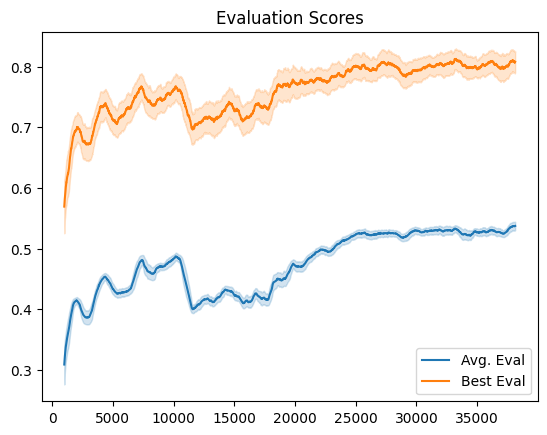

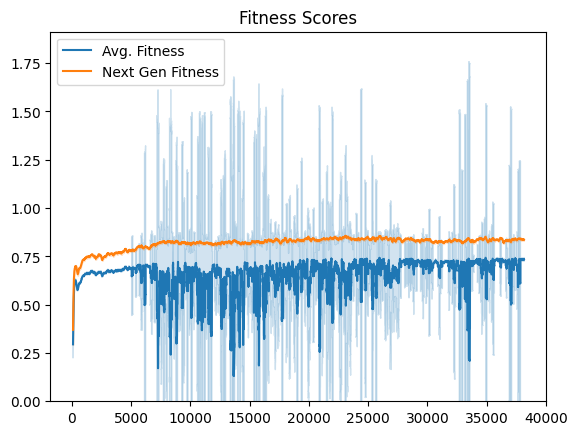

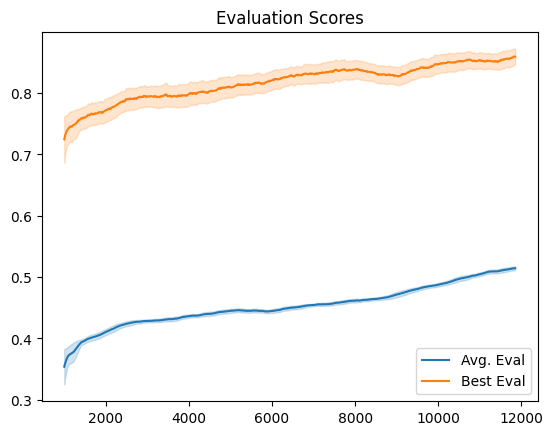

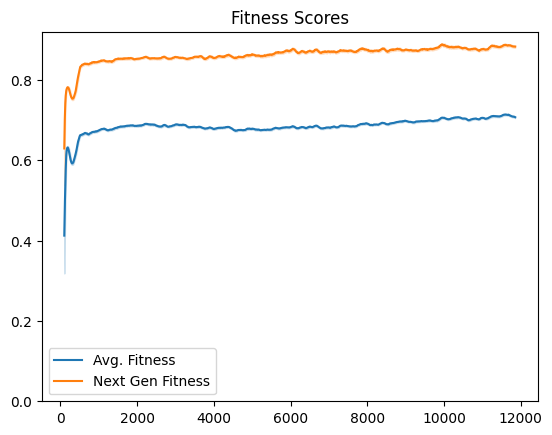

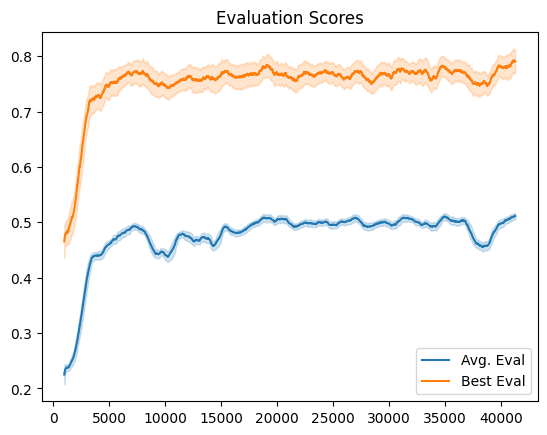

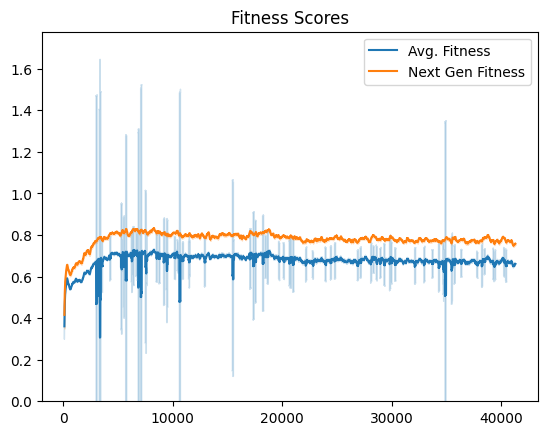

In [10]:
plot_progress('defaults', 'Default')
plot_progress('large_pop', 'Large Population')
plot_progress('rand_init', 'Random Initialization')